In [1]:
# Importing libraries
import pandas as pd
import numpy as np

In [2]:
train_data = pd.read_csv(r'/kaggle/input/playground-series-s4e1/train.csv')
test_data = pd.read_csv(r'/kaggle/input/playground-series-s4e1/test.csv')

In [3]:
# Display top 5 rows of the dataset
# Aim - to check whether the customer has left the bank or not
train_data.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [4]:
# Display last 5 rows of the dataset
train_data.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
165029,165029,15667085,Meng,667,Spain,Female,33.0,2,0.0,1,1.0,1.0,131834.75,0
165030,165030,15665521,Okechukwu,792,France,Male,35.0,3,0.0,1,0.0,0.0,131834.45,0
165031,165031,15664752,Hsia,565,France,Male,31.0,5,0.0,1,1.0,1.0,127429.56,0
165032,165032,15689614,Hsiung,554,Spain,Female,30.0,7,161533.0,1,0.0,1.0,71173.03,0
165033,165033,15732798,Ulyanov,850,France,Male,31.0,1,0.0,1,1.0,0.0,61581.79,1


In [5]:
# Find shape of our dataset i.e. no. of rows and no. of columns
train_data.shape

(165034, 14)

In [6]:
print("No. of rows", train_data.shape[0])
print("No. of columns", train_data.shape[1])

No. of rows 165034
No. of columns 14


In [7]:
# Get information about the dataset i.e. datatypes of columns, memory requirement
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [8]:
# Check null values in the dataset
# data.isnull() # display the data as boolean values
train_data.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
# Overall statistics about the dataset
# By default it will display statistics for numeric data
train_data.describe(include='all')

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034,165034.000000,165034,165034,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
unique,NaN,NaN,2797,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Hsia,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2456,NaN,94215,93150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,82516.5000,1.569201e+07,NaN,656.454373,NaN,NaN,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,NaN,80.103340,NaN,NaN,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,NaN,597.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,NaN,659.000000,NaN,NaN,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,NaN,710.000000,NaN,NaN,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000


In [10]:
# Display column names
train_data.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [11]:
# Dropping irrelevant features
train_data = train_data.drop(['CustomerId','Surname'], axis=1)

In [12]:
train_data.head()

,id,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


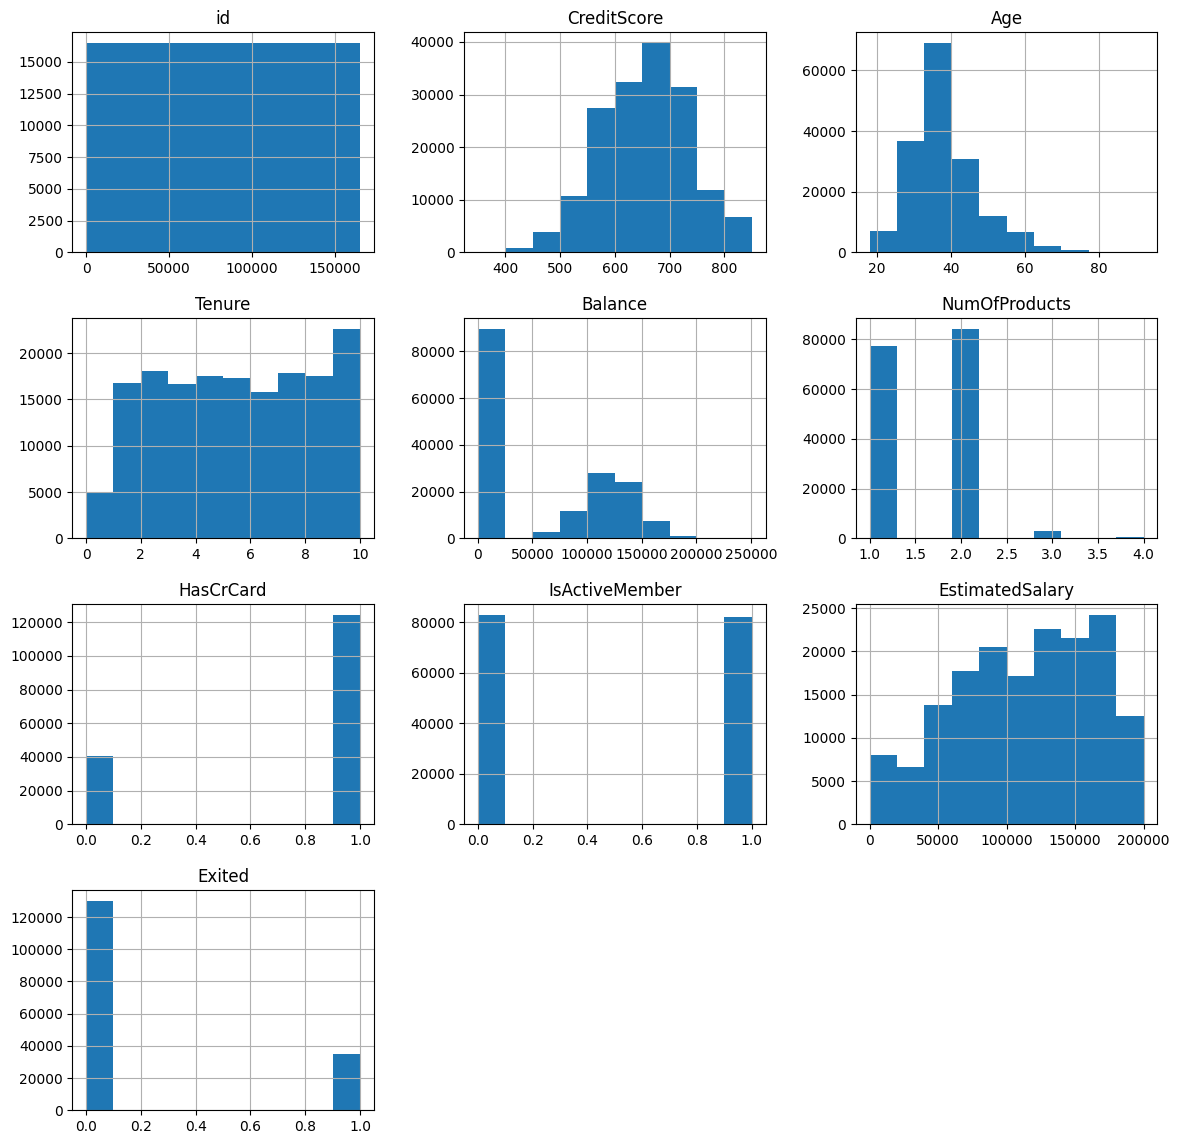

In [13]:
#Plot histogram grid
from matplotlib import pyplot as plt
train_data.hist(figsize=(14,14))
plt.show()

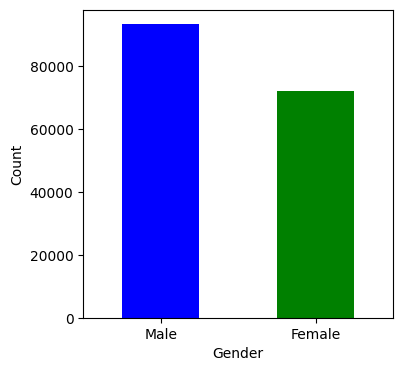

Counter({'Male': 93150, 'Female': 71884})

In [14]:
# Bar plot for "Gender"
from collections import Counter
plt.figure(figsize=(4,4))
train_data['Gender'].value_counts().plot.bar(color=['b', 'g'])
plt.ylabel('Count')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.show()

# Display count of each class
Counter(train_data.Gender)

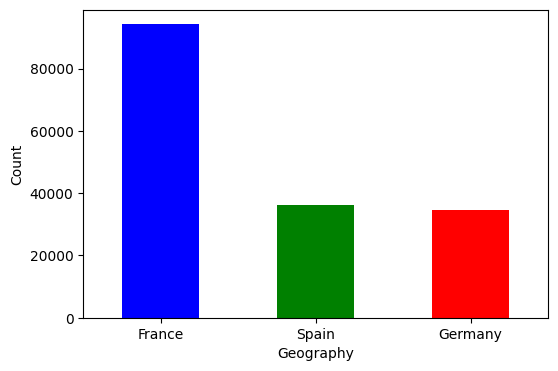

Counter({'France': 94215, 'Spain': 36213, 'Germany': 34606})

In [15]:
# Bar plot for "Geography"
plt.figure(figsize=(6,4))
train_data['Geography'].value_counts().plot.bar(color=['b', 'g', 'r'])
plt.ylabel('Count')
plt.xlabel('Geography')
plt.xticks(rotation=0)
plt.show()

# Display count of each class
Counter(train_data.Geography)

<Axes: >

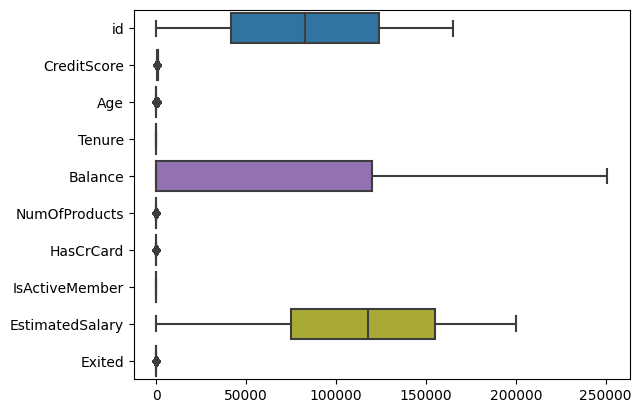

In [16]:
import seaborn as sns
sns.boxplot(train_data,orient='h')

In [17]:
# Encoding categorical data
# Convert categorical values into numbers
train_data['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [18]:
# passing data directly to this will create dummy variable trap
# scenario in which these dummy variables are highly correlated that means one variable can be predicted from others
# pd.get_dummies(data)
# In this case 3 columns France, Germany and Spain are created
# From any 2 columns we can easily predict the 3rd column. In this case, we will drop the first column
train_data = pd.get_dummies(train_data, drop_first = True)

In [19]:
train_data.head()

,id,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,0,668,33.0,3,0.00,2,1.0,0.0,181449.97,0,False,False,True
1,1,627,33.0,1,0.00,2,1.0,1.0,49503.50,0,False,False,True
2,2,678,40.0,10,0.00,2,1.0,0.0,184866.69,0,False,False,True
3,3,581,34.0,2,148882.54,1,1.0,1.0,84560.88,0,False,False,True
4,4,716,33.0,5,0.00,2,1.0,1.0,15068.83,0,False,True,True


<Axes: >

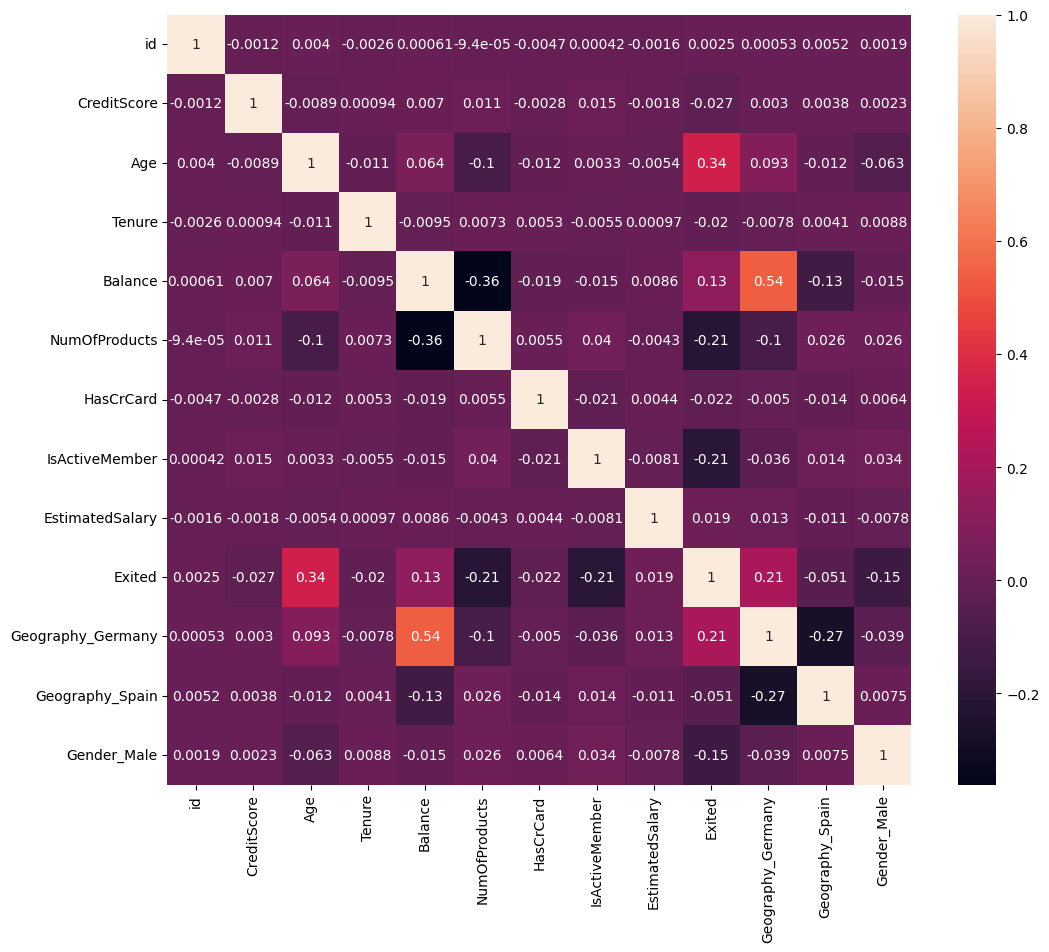

In [20]:
#Heatmap for expressing correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))  # Adjust width and height as needed
sns.heatmap(train_data.iloc[:,0:15].corr(),annot=True)

In [21]:
test_data.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00


In [22]:
test_data.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
110018,275052,15662091,P'eng,570,Spain,Male,29.0,7,116099.82,1,1.0,1.0,148087.62
110019,275053,15774133,Cox,575,France,Female,36.0,4,178032.53,1,1.0,1.0,42181.68
110020,275054,15728456,Ch'iu,712,France,Male,31.0,2,0.00,2,1.0,0.0,16287.38
110021,275055,15687541,Yegorova,709,France,Female,32.0,3,0.00,1,1.0,1.0,158816.58
110022,275056,15663942,Tuan,621,France,Female,37.0,7,87848.39,1,1.0,0.0,24210.56


In [23]:
test_data.shape

(110023, 13)

In [24]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110023 entries, 0 to 110022
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               110023 non-null  int64  
 1   CustomerId       110023 non-null  int64  
 2   Surname          110023 non-null  object 
 3   CreditScore      110023 non-null  int64  
 4   Geography        110023 non-null  object 
 5   Gender           110023 non-null  object 
 6   Age              110023 non-null  float64
 7   Tenure           110023 non-null  int64  
 8   Balance          110023 non-null  float64
 9   NumOfProducts    110023 non-null  int64  
 10  HasCrCard        110023 non-null  float64
 11  IsActiveMember   110023 non-null  float64
 12  EstimatedSalary  110023 non-null  float64
dtypes: float64(5), int64(5), object(3)
memory usage: 10.9+ MB


In [25]:
test_data.describe(include='all')

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,110023.000000,1.100230e+05,110023,110023.000000,110023,110023,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000
unique,NaN,NaN,2708,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Hsia,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1606,NaN,63171,61942,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,220045.000000,1.569210e+07,NaN,656.530789,NaN,NaN,38.122205,4.996637,55333.611354,1.553321,0.753043,0.495233,112315.147765
std,31761.048671,7.168499e+04,NaN,80.315415,NaN,NaN,8.861550,2.806148,62788.519675,0.544714,0.431244,0.499980,50277.048244
min,165034.000000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,192539.500000,1.563286e+07,NaN,597.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74440.325000
50%,220045.000000,1.569018e+07,NaN,660.000000,NaN,NaN,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117832.230000
75%,247550.500000,1.575693e+07,NaN,710.000000,NaN,NaN,42.000000,7.000000,120145.605000,2.000000,1.000000,1.000000,154631.350000


In [26]:
test_data = test_data.drop(['CustomerId','Surname'], axis=1)

In [27]:
test_data = pd.get_dummies(test_data, drop_first = True)

In [28]:
# Not handling imbalanced data
# Imbalanced data - where the target class has uneven distribution
train_data['Exited'].value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

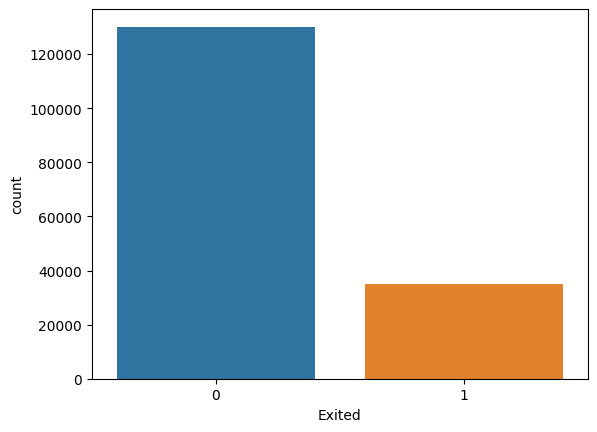

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=train_data['Exited'])
plt.show()

In [30]:
# Handle imbalance dataset with SMOTE
# oversampling - oversample the minority class with replacement
# undersampling - randomly delete rows from majority class
# undersampling is avoided as we can loose valuable data
# SMOTE stands synthetic minority oversampling
# SMOTE generates virtual training records by linear interpolation for the minority class
# we are not generating duplicate data points but creating synthetic data points that are slightly different from original data points

In [31]:
X = train_data.drop('Exited',axis=1)
X

,id,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,0,668,33.0,3,0.00,2,1.0,0.0,181449.97,False,False,True
1,1,627,33.0,1,0.00,2,1.0,1.0,49503.50,False,False,True
2,2,678,40.0,10,0.00,2,1.0,0.0,184866.69,False,False,True
3,3,581,34.0,2,148882.54,1,1.0,1.0,84560.88,False,False,True
4,4,716,33.0,5,0.00,2,1.0,1.0,15068.83,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
165029,165029,667,33.0,2,0.00,1,1.0,1.0,131834.75,False,True,False
165030,165030,792,35.0,3,0.00,1,0.0,0.0,131834.45,False,False,True
165031,165031,565,31.0,5,0.00,1,1.0,1.0,127429.56,False,False,True
165032,165032,554,30.0,7,161533.00,1,0.0,1.0,71173.03,False,True,False


In [32]:
y = train_data['Exited']
y

0         0
1         0
2         0
3         0
4         0
         ..
165029    0
165030    0
165031    0
165032    0
165033    1
Name: Exited, Length: 165034, dtype: int64

In [33]:
from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE().fit_resample(X,y)

In [34]:
y_res.value_counts()

Exited
0    130113
1    130113
Name: count, dtype: int64

In [35]:
# Split data into train set and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.20, random_state=42)

In [36]:
# Feature Scaling
# All linear machine learning algorithms require feature scaling. Ex KNN, ANN, Support vectors, Linear Regression and logistic Regression
# Non- linear machine learning algorithms are decision tree, random forest
# The algorithm that is not distance based is not affected by feature scaling

In [37]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.fit_transform(X_test)

In [38]:
X_train

,id,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
71953,71953,579,45.000000,1,0.000000,1,0.0,0.000000,104982.500000,False,False,True
71122,71122,709,50.000000,4,0.000000,2,0.0,1.000000,5078.900000,False,False,True
103096,103096,683,41.000000,5,128750.790000,1,1.0,0.000000,115262.090000,True,False,True
124963,124963,695,39.000000,6,0.000000,2,1.0,0.000000,173870.390000,False,False,True
198466,97371,582,55.272817,5,118242.372805,1,1.0,0.927282,80533.984574,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
259178,8147,568,53.394137,2,0.000000,1,1.0,0.154904,152335.593232,False,True,True
103694,103694,751,43.000000,7,0.000000,2,1.0,0.000000,88866.390000,False,False,True
131932,131932,753,39.000000,7,0.000000,2,1.0,0.000000,167973.630000,False,False,False
146867,146867,685,48.000000,4,0.000000,2,1.0,1.000000,24998.750000,False,False,False


In [39]:
# Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression(random_state = 42) # create an instance of it
log.fit(X_train, y_train)
y_pred1 = log.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy_score(y_test,y_pred1)

0.6950774315029012

In [42]:
precision_score(y_test,y_pred1) # pc=TP/(FP+TP)

0.692561169608363

In [43]:
recall_score(y_test,y_pred1) # rc=TP(TP+FN)

0.7022428757969122

In [44]:
f1_score(y_test,y_pred1)

0.6973684210526315

In [45]:
# KNeighbours Classifier

In [46]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [47]:
y_pred2 = knn.predict(X_test)

In [48]:
accuracy_score(y_test,y_pred2)

0.7016101141298082

In [49]:
precision_score(y_test,y_pred2)

0.6664871031117308

In [50]:
recall_score(y_test,y_pred2)

0.8077809355557263

In [51]:
f1_score(y_test,y_pred2)

0.7303632196680324

In [52]:
# Decision Tree Classifier

In [53]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [54]:
y_pred3 = dt.predict(X_test)

In [55]:
accuracy_score(y_test,y_pred3)

0.8617953348960535

In [56]:
precision_score(y_test,y_pred3)

0.856980488728926

In [57]:
recall_score(y_test,y_pred3)

0.8687303172286658

In [58]:
f1_score(y_test,y_pred3)

0.8628154025136842

In [59]:
# Random Forest Classifier

In [60]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42,max_depth=5,min_samples_leaf=5,min_samples_split=5,criterion='gini')
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=5,
                       random_state=42)

In [61]:
y_pred4 = rf.predict(X_test)

In [62]:
accuracy_score(y_test,y_pred4)

0.863639857049533

In [63]:
precision_score(y_test,y_pred4)

0.86757228798758

In [64]:
recall_score(y_test,y_pred4)

0.8584760734311391

In [65]:
f1_score(y_test,y_pred4)

0.8630002123429146

In [66]:
# Gradient Boosting Classifier

In [67]:
import xgboost as xgb
gbc = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
gbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [68]:
y_pred5 = gbc.predict(X_test)

In [69]:
accuracy_score(y_test,y_pred5)

0.9031433731698881

In [70]:
precision_score(y_test,y_pred5)

0.9262657842380934

In [71]:
recall_score(y_test,y_pred5)

0.8761425608725708

In [72]:
f1_score(y_test,y_pred5)

0.9005072335050427

In [73]:
from lightgbm import LGBMClassifier

In [74]:
lgb = LGBMClassifier(random_state=42)
lgb.fit(X_train, y_train)
y_pred6 = lgb.predict(X_test)

In [75]:
accuracy_score(y_test,y_pred6)

0.9085424432233025

In [76]:
precision_score(y_test,y_pred6)

0.9297891249899006

In [77]:
recall_score(y_test,y_pred6)

0.8839388585912896

In [78]:
f1_score(y_test,y_pred6)

0.9062844542447629

In [79]:
final_data = pd.DataFrame({'Models':['LR','KNN','DT','RF','GBC','LGB'],
                          'Accuracy': [accuracy_score(y_test, y_pred1), accuracy_score(y_test, y_pred2), accuracy_score(y_test, y_pred3), accuracy_score(y_test, y_pred4), accuracy_score(y_test, y_pred5), accuracy_score(y_test,y_pred6)]
                          })

In [80]:
final_data

,Models,Accuracy
0,LR,0.695077
1,KNN,0.701610
2,DT,0.861795
3,RF,0.863640
4,GBC,0.903143
5,LGB,0.908542


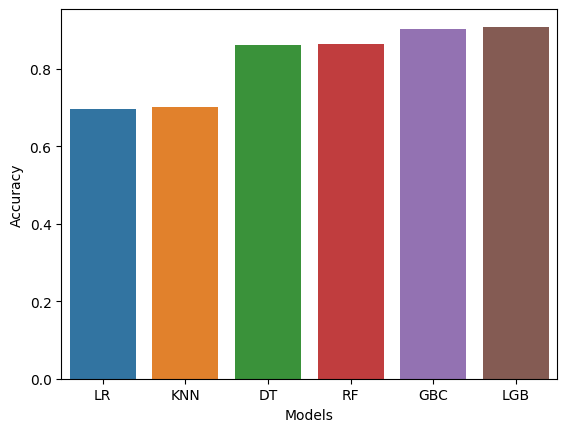

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Models', y='Accuracy', data=final_data)
plt.show()

In [82]:
final_data = pd.DataFrame({'Models':['LR','KNN','DT','RF','GBC','LGB'],
                          'Precision': [precision_score(y_test, y_pred1), precision_score(y_test, y_pred2), precision_score(y_test, y_pred3), precision_score(y_test, y_pred4), precision_score(y_test, y_pred5), precision_score(y_test, y_pred6)]
                          })

In [83]:
final_data

,Models,Precision
0,LR,0.692561
1,KNN,0.666487
2,DT,0.856980
3,RF,0.867572
4,GBC,0.926266
5,LGB,0.929789


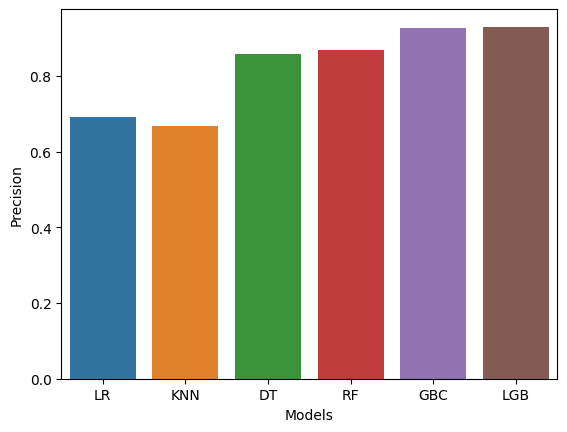

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Models', y='Precision', data=final_data)
plt.show()

In [85]:
final_data = pd.DataFrame({'Models':['LR','KNN','DT','RF','GBC','LGB'],
                          'Recall': [recall_score(y_test, y_pred1), recall_score(y_test, y_pred2), recall_score(y_test, y_pred3), recall_score(y_test, y_pred4), recall_score(y_test, y_pred5), recall_score(y_test,y_pred6)]
                          })

In [86]:
final_data

,Models,Recall
0,LR,0.702243
1,KNN,0.807781
2,DT,0.868730
3,RF,0.858476
4,GBC,0.876143
5,LGB,0.883939


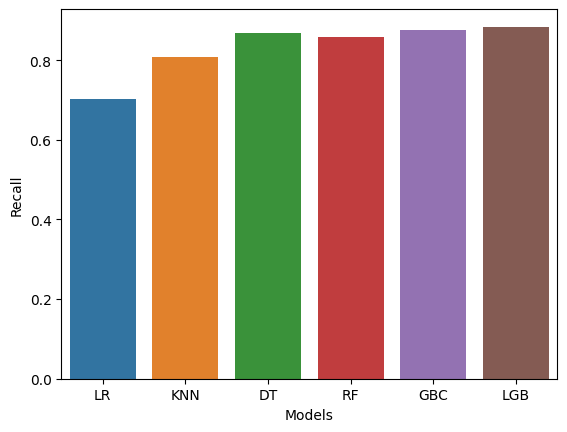

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Models', y='Recall', data=final_data)
plt.show()

In [88]:
y_pred = lgb.predict(test_data)

In [89]:
predictions = pd.DataFrame({"id": test_data['id'],"Exited": y_pred})
predictions["Exited"] = predictions["Exited"].round(2).astype(int)

In [90]:
predictions.to_csv("submission.csv",index=False)